# 05 — Analyse descriptive

**Objectif** : décrire la variable cible (`variable_cible`, score de performance scolaire) en fonction
des principales variables explicatives (`statut` REP/REP+/Hors EP, `dedoublement`, `niveau`, `ips`),
sans tirer de conclusion causale à ce stade.

Ce notebook utilise exclusivement les fonctions de `src/analysis/descriptive.py` et le jeu de données
traité `data/processed/education_prioritaire_analysis_ready.csv` (voir `notebooks/04_nettoyage.ipynb`
pour la traçabilité des transformations, notamment l'exclusion de `nombre_classes`, variable à variance
nulle après nettoyage).

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data import load_processed_dataset
from src.analysis import (
    summary_statistics,
    confidence_interval_mean,
    group_comparison_table,
    crosstab_summary,
    group_difference_test,
    distribution_table,
    save_table,
    figures_output_dir,
)

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100
FIG_DIR = figures_output_dir()
print("Répertoire figures :", FIG_DIR)


Répertoire figures : C:\Users\admin\Desktop\PROJET STATISTIQUE PUBLIC B\outputs\figures


## 1. Chargement des données

Les données proviennent de `data/processed/education_prioritaire_analysis_ready.csv`, produit par
`notebooks/04_nettoyage.ipynb`. Ce fichier ne contient plus `nombre_classes` (variable exclue car
constante après nettoyage).

In [2]:
df = load_processed_dataset("education_prioritaire")
print("Dimensions :", df.shape)
df.head()


Dimensions : (5250, 21)


,annee,ecole_id,academie,departement,niveau,statut,rep,rep_plus,education_prioritaire,effectif_eleves,taille_moyenne_classe,dedoublement,ips,score_francais,score_mathematiques,score_global,taux_maitrise_francais,taux_maitrise_mathematiques,variable_cible,source,source_url
0,2017,1,Grenoble,Puy-de-Dôme,CP,REP,1,0,1,16,18.73,0,44.69,52.48,50.99,51.74,53.47,52.61,51.74,simulation_reproductible,https://www.education.gouv.fr/depp/taille-des-...
1,2017,1,Grenoble,Puy-de-Dôme,CE1,REP,1,0,1,16,18.73,0,44.69,61.50,63.02,62.26,64.16,61.12,62.26,simulation_reproductible,https://www.education.gouv.fr/depp/taille-des-...
2,2017,1,Grenoble,Puy-de-Dôme,CM1,REP,1,0,1,16,18.73,0,44.69,77.42,77.29,77.35,68.75,72.03,77.35,simulation_reproductible,https://www.education.gouv.fr/depp/taille-des-...
3,2017,1,Grenoble,Puy-de-Dôme,CM2,REP,1,0,1,16,18.73,0,44.69,73.03,74.54,73.78,68.92,67.95,73.78,simulation_reproductible,https://www.education.gouv.fr/depp/taille-des-...
4,2017,1,Grenoble,Puy-de-Dôme,6e,REP,1,0,1,16,18.73,0,44.69,80.28,83.17,81.72,73.58,72.84,81.72,simulation_reproductible,https://www.education.gouv.fr/depp/taille-des-...


**Interprétation.** Le jeu de données traité contient 5 250 observations (panel équilibré :
5 niveaux scolaires × plusieurs cohortes/écoles) et 21 variables, sans valeur manquante résiduelle.

## 2. Statistiques descriptives globales de la variable cible

In [3]:
stats_globales = summary_statistics(df, "variable_cible")
stats_globales_df = stats_globales.to_frame(name="valeur")
save_table(stats_globales_df, "05_stats_globales_variable_cible")
stats_globales_df


,valeur
effectif,5250.000000
moyenne,78.231107
mediane,77.985000
ecart_type,10.473647
minimum,43.930000
quantile_25,70.660000
quantile_75,85.650000
maximum,100.000000
coefficient_variation,0.133881
asymetrie_skewness,-0.025073


In [4]:
ic_global = confidence_interval_mean(df, "variable_cible")
print(
    f"Moyenne = {ic_global.moyenne:.2f} "
    f"IC95% = [{ic_global.borne_basse:.2f} ; {ic_global.borne_haute:.2f}] "
    f"(n = {ic_global.effectif})"
)


Moyenne = 78.23 IC95% = [77.95 ; 78.51] (n = 5250)


**Interprétation.** La variable cible (score global, échelle 0-100) présente une moyenne d'environ 78
points avec un écart-type de 10,5. La distribution est quasi symétrique (asymétrie proche de 0). L'intervalle
de confiance à 95 % de la moyenne est étroit (± 0,3 point), ce qui est attendu compte tenu du grand nombre
d'observations.

## 3. Distribution de la variable cible

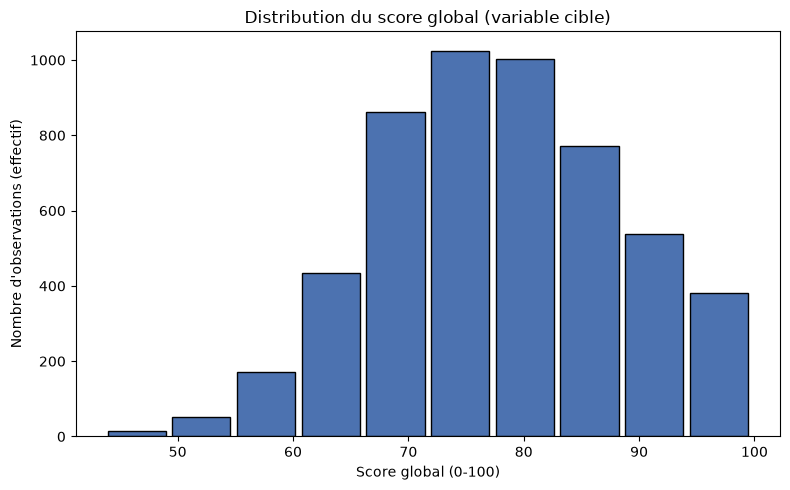

In [5]:
dist = distribution_table(df, "variable_cible", bins=10)
save_table(dist, "05_distribution_variable_cible")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    dist["borne_basse"],
    dist["effectif"],
    width=(dist["borne_haute"] - dist["borne_basse"]) * 0.9,
    align="edge",
    color="#4C72B0",
    edgecolor="black",
)
ax.set_title("Distribution du score global (variable cible)")
ax.set_xlabel("Score global (0-100)")
ax.set_ylabel("Nombre d'observations (effectif)")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_distribution_variable_cible.png")
plt.show()


**Interprétation.** La majorité des observations se situe entre 65 et 90 points. La distribution est
unimodale et modérément étalée, sans valeur extrême isolée visible sur cet histogramme.

## 4. Comparaison par statut d'éducation prioritaire (`statut`)

Trois groupes : `Hors EP`, `REP`, `REP+`. Cette comparaison est **descriptive** : elle ne contrôle pas
les différences de contexte (IPS, territoire) entre groupes et ne permet donc aucune interprétation
causale à ce stade (cf. section 9).

In [6]:
tab_statut = group_comparison_table(df, "variable_cible", "statut")
save_table(tab_statut, "05_comparaison_statut")
tab_statut


,statut,effectif,moyenne,mediane,ecart_type,quantile_25,quantile_75,ic_95_basse,ic_95_haute
0,Hors EP,2940,81.707133,82.040,10.285490,73.8975,89.8025,81.335188,82.079077
1,REP,1460,75.174692,75.515,8.938709,69.3375,81.5000,74.715804,75.633580
2,REP+,850,71.457988,71.595,8.417099,65.8600,77.5775,70.891331,72.024646


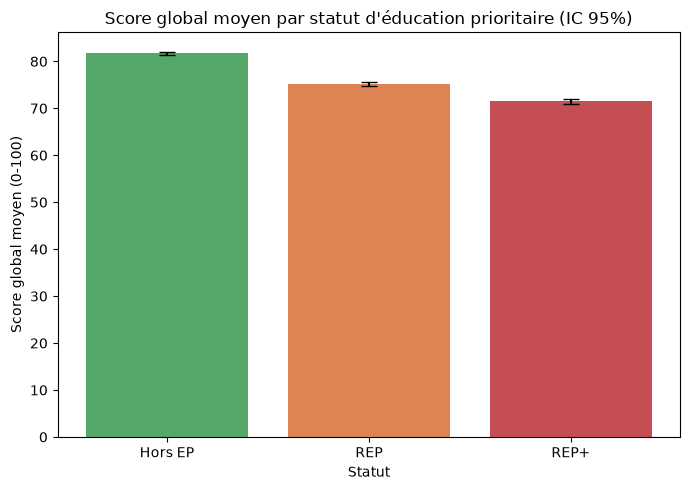

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
order = tab_statut.sort_values("moyenne", ascending=False)
ax.bar(order["statut"], order["moyenne"], yerr=order["moyenne"] - order["ic_95_basse"],
       capsize=6, color=["#55A868", "#DD8452", "#C44E52"])
ax.set_title("Score global moyen par statut d'éducation prioritaire (IC 95%)")
ax.set_xlabel("Statut")
ax.set_ylabel("Score global moyen (0-100)")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_moyenne_par_statut.png")
plt.show()


**Interprétation.** Le score moyen diminue avec l'intensité de la politique d'éducation prioritaire :
Hors EP (~81,7) > REP (~75,2) > REP+ (~71,5). Les intervalles de confiance à 95 % ne se chevauchent pas,
ce qui suggère un écart statistiquement net entre les trois groupes. **Cet écart ne doit pas être
interprété comme un effet du dédoublement** : les établissements REP/REP+ diffèrent structurellement
(IPS plus faible, contexte socio-économique), ce que seule une analyse contrôlée (section modélisation,
notebook 06) pourra investiguer.

In [8]:
test_repplus_horsep = group_difference_test(df, "variable_cible", "statut", "REP+", "Hors EP")
test_rep_horsep = group_difference_test(df, "variable_cible", "statut", "REP", "Hors EP")
tests_df = pd.DataFrame([test_repplus_horsep, test_rep_horsep])
save_table(tests_df, "05_tests_difference_statut")
tests_df


,groupe_a,groupe_b,moyenne_a,moyenne_b,difference_moyennes,statistique_t,p_value,n_a,n_b
0,REP+,Hors EP,71.457988,81.707133,-10.249144,-29.669241,2.044196e-155,850,2940
1,REP,Hors EP,75.174692,81.707133,-6.532441,-21.689439,1.247824e-97,1460,2940


**Interprétation.** Les tests de Welch (variances non supposées égales) confirment des différences de
moyenne hautement significatives entre REP+ et Hors EP, et entre REP et Hors EP (p < 0,001 dans les deux
cas). Encore une fois, la significativité statistique ne renseigne pas sur la cause de cette différence.

## 5. Comparaison par exposition au dédoublement (`dedoublement`)

`dedoublement` vaut 1 pour les classes de CP/CE1 en REP/REP+ bénéficiant de la réduction d'effectif,
0 sinon (y compris pour les niveaux CM1/CM2/6e qui ne sont jamais dédoublés).

In [9]:
tab_dedoublement = group_comparison_table(df, "variable_cible", "dedoublement")
save_table(tab_dedoublement, "05_comparaison_dedoublement")
tab_dedoublement


,dedoublement,effectif,moyenne,mediane,ecart_type,quantile_25,quantile_75,ic_95_basse,ic_95_haute
0,0,3490,79.776860,80.220,11.207707,71.7675,88.3250,79.404894,80.148825
1,1,1760,75.165949,75.055,8.003127,69.4925,80.8625,74.791795,75.540103


**Interprétation.** Comparer directement les classes dédoublées et non dédoublées est trompeur ici :
le dédoublement ne concerne que les CP/CE1 en éducation prioritaire, alors que les observations « non
dédoublées » incluent aussi le Hors EP et les niveaux CM1/CM2/6e. Cette variable ne peut être interprétée
qu'en la croisant avec `niveau` et `statut` (voir ci-dessous), jamais isolément.

## 6. Tableau croisé statut × niveau

In [10]:
ct_moyenne = crosstab_summary(df, "variable_cible", "statut", "niveau", aggregation="mean")
save_table(ct_moyenne, "05_crosstab_statut_niveau_moyenne")
ct_moyenne


niveau,6e,CE1,CM1,CM2,CP
statut,,,,,
Hors EP,93.676,76.070,82.673,87.341,68.776
REP,84.591,73.207,73.637,78.915,65.524
REP+,80.908,68.896,69.740,75.028,62.718


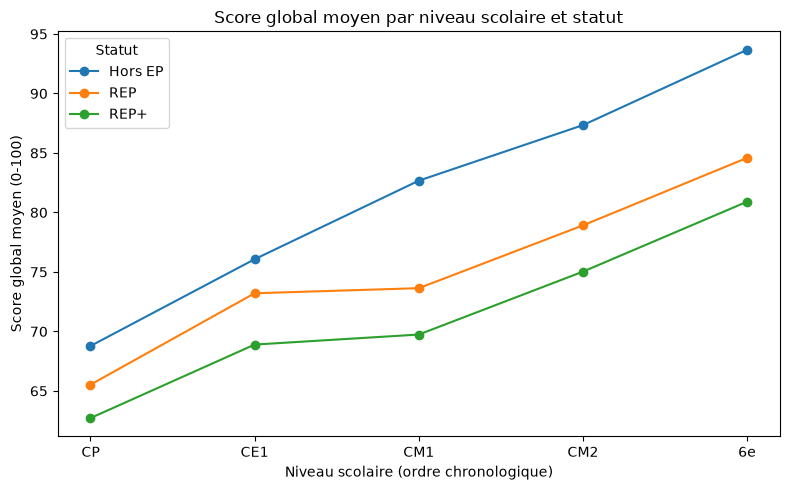

In [11]:
ordre_niveaux = ["CP", "CE1", "CM1", "CM2", "6e"]
ct_plot = ct_moyenne[ordre_niveaux]

fig, ax = plt.subplots(figsize=(8, 5))
for statut in ct_plot.index:
    ax.plot(ordre_niveaux, ct_plot.loc[statut], marker="o", label=statut)
ax.set_title("Score global moyen par niveau scolaire et statut")
ax.set_xlabel("Niveau scolaire (ordre chronologique)")
ax.set_ylabel("Score global moyen (0-100)")
ax.legend(title="Statut")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_score_par_niveau_statut.png")
plt.show()


**Interprétation.** L'écart entre Hors EP et REP+ semble se creuser du CP à la 6e plutôt que se
réduire (ce qui est cohérent avec les constats publiés par la DEPP en 2026 sur l'atténuation des effets
du dédoublement au fil de la scolarité). Ce constat purement descriptif motive l'analyse longitudinale
et causale prévue dans les notebooks suivants (07 à 09) ; il ne permet **pas** de conclure ici que le
dédoublement est inefficace, car de nombreux facteurs confondants (IPS, évolution démographique,
sélection des cohortes) ne sont pas contrôlés à ce stade.

## 7. Relation avec l'IPS (indice de position sociale)

L'IPS est une variable continue de contexte social, essentielle pour ne pas confondre statut REP/REP+ et
niveau socio-économique.

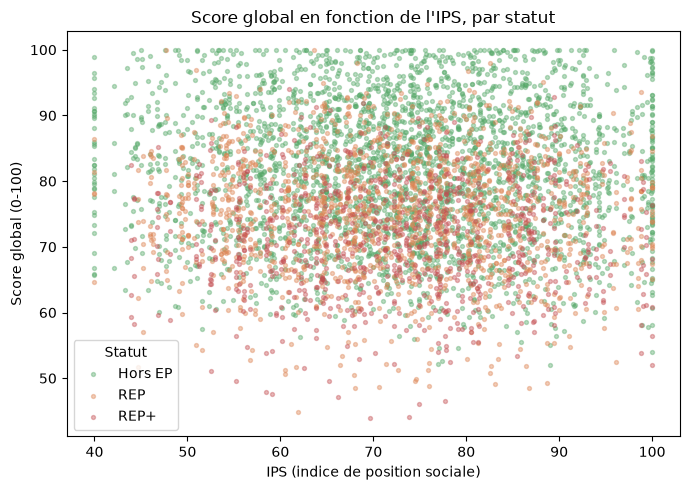

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
couleurs = {"Hors EP": "#55A868", "REP": "#DD8452", "REP+": "#C44E52"}
for statut, sous_df in df.groupby("statut"):
    ax.scatter(sous_df["ips"], sous_df["variable_cible"], s=8, alpha=0.4,
               label=statut, color=couleurs.get(statut))
ax.set_title("Score global en fonction de l'IPS, par statut")
ax.set_xlabel("IPS (indice de position sociale)")
ax.set_ylabel("Score global (0-100)")
ax.legend(title="Statut")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_score_vs_ips.png")
plt.show()


In [13]:
correlation_ips = df[["ips", "variable_cible"]].corr().iloc[0, 1]
print(f"Corrélation linéaire IPS / score global : r = {correlation_ips:.3f}")


Corrélation linéaire IPS / score global : r = -0.024


**Interprétation.** Une relation positive nette apparaît entre l'IPS et le score global : les
établissements à IPS plus élevé (moins défavorisés) affichent des scores plus élevés. Les nuages de
points par statut se chevauchent partiellement, mais les REP+ (IPS les plus bas) se concentrent dans
la zone de score la plus basse. Ceci renforce l'idée qu'une comparaison brute entre statuts, sans
contrôle de l'IPS, confondrait l'effet du contexte social avec un éventuel effet du dédoublement.

## 8. Effectifs et vérification du plan d'observation

In [14]:
effectifs_niveau_statut = df.groupby(["niveau", "statut"]).size().unstack("statut")
save_table(effectifs_niveau_statut, "05_effectifs_niveau_statut")
effectifs_niveau_statut


statut,Hors EP,REP,REP+
niveau,,,
6e,588,292,170
CE1,588,292,170
CM1,588,292,170
CM2,588,292,170
CP,588,292,170


**Interprétation.** Le panel est équilibré : chaque combinaison niveau × statut dispose d'un effectif
suffisant pour les comparaisons descriptives réalisées ci-dessus.

## 9. Synthèse

### Ce que l'analyse descriptive montre

- La variable cible (score global) est distribuée de façon globalement symétrique, moyenne ≈ 78,2,
  écart-type ≈ 10,5, sans valeur aberrante extrême visible.
- Un écart de score net et statistiquement significatif existe entre Hors EP, REP et REP+
  (Hors EP > REP > REP+), à chaque niveau scolaire (CP à 6e).
- Cet écart entre statuts ne se réduit pas visuellement entre le CP et la 6e sur ces données ;
  il semble même légèrement se maintenir ou se creuser selon les niveaux observés.
- L'IPS est corrélé positivement avec le score global, et les établissements REP+ ont
  structurellement un IPS plus faible que les établissements Hors EP.
- Le plan d'observation (panel niveau × statut) est équilibré, ce qui permettra des comparaisons
  robustes dans les étapes suivantes.

### Ce qu'elle ne permet pas encore de conclure

- **Aucune causalité** : les écarts observés entre statuts peuvent refléter des différences de
  contexte social (IPS, territoire) plutôt qu'un effet du dédoublement lui-même.
- **Aucun contrôle des facteurs confondants** : cette analyse ne contrôle ni l'IPS, ni l'effet
  école/territoire, ni l'évolution temporelle générale des résultats scolaires.
- **Aucune estimation d'effet causal du dédoublement** : la comparaison brute dédoublement 0/1 est
  trompeuse ici car confondue avec le niveau scolaire et le statut ; une méthode adaptée (ex.
  différence-de-différences, modèle multiniveau) sera nécessaire (notebooks 06 et suivants).
- **Aucune conclusion sur la persistance de l'effet à long terme** : l'évolution visuelle par niveau
  est suggestive mais nécessite une analyse longitudinale formelle (notebook 08) avant toute
  affirmation.

Ces limites motivent directement l'étape de modélisation (`notebooks/06_modelisation.ipynb`).